# 실습 6-2 : STUCCO (대조집합 학습)

#### **<실습 내용>**

1. 대조집합 학습 개요
- STUCCO 알고리즘 원리

2. STUCCO 기본 예제 (Process_Data)
- 데이터 전처리 (연속형 변수 범주화)
- 대조집합(cset) 도출 및 해석

3. Vibe Coding 실습 (통신사 고객 이탈 데이터)

## 분석 준비

### 주요 라이브러리 호출

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import logging
from stucco import ContrastSetLearner  # 대조집합 학습(Contrast Set Learning)을 수행하는 STUCCO 알고리즘 구현체

logging.getLogger().setLevel(logging.WARNING)  # stucco.py의 상세 진행 로그 숨기기

---

## 1) 데이터 불러오기

In [2]:
data = pd.read_csv("dataset/day6-2_data.csv")
print("데이터 크기:", data.shape)
data.head()

데이터 크기: (596, 12)


,Prod_ID,M1,M2,P1,P2,P3,C1,C2,P4,P5,P6,Y
0,1001001,15,E,A,B,D,110.192,27.049,A,A,B,0
1,1001002,20,E,A,B,D,109.940,27.215,A,A,A,0
2,1001003,15,U,A,B,B,110.214,27.444,B,B,B,4
3,1001004,25,K,B,B,C,107.260,27.300,A,A,C,0
4,1001005,20,E,A,A,D,105.026,28.283,B,B,A,0


In [3]:
# 불량 기준 설정: 제품 1개당 불량 개수(Y)가 3개 이상이면 Fault, 아니면 Pass로 그룹 라벨 생성
data["Fail"] = ["Fault" if i >= 3 else "Pass" for i in data["Y"]]
data

,Prod_ID,M1,M2,P1,P2,P3,C1,C2,P4,P5,P6,Y,Fail
0,1001001,15,E,A,B,D,110.192,27.049,A,A,B,0,Pass
1,1001002,20,E,A,B,D,109.940,27.215,A,A,A,0,Pass
2,1001003,15,U,A,B,B,110.214,27.444,B,B,B,4,Fault
3,1001004,25,K,B,B,C,107.260,27.300,A,A,C,0,Pass
4,1001005,20,E,A,A,D,105.026,28.283,B,B,A,0,Pass
...,...,...,...,...,...,...,...,...,...,...,...,...,...
591,1001592,15,E,A,C,D,115.153,31.652,A,A,C,0,Pass
592,1001593,15,E,A,B,D,114.593,33.890,A,A,B,0,Pass
593,1001594,20,U,A,A,B,105.724,33.251,B,B,A,0,Pass
594,1001595,25,E,A,A,A,109.783,32.054,A,A,D,0,Pass


In [4]:
print("클래스 분포:")
print(data["Fail"].value_counts())

클래스 분포:
Fail
Pass     471
Fault    125
Name: count, dtype: int64


**활용할 반도체 공정 데이터 소개 (6-1과 동일)**

| 변수 | 설명 |
|---|---|
| Prod_ID | 제품 고유 ID |
| M1 | 공정 설비 온도 설정값 (15/20/25/30) |
| M2 | 사용 설비 ID (E, U, K) |
| P1 ~ P6 | 제품 설계/공정 옵션 (범주형 파라미터) |
| C1, C2 | 공정 중 측정된 연속형 값 |
| Y | 제품 1개당 발생한 불량 개수 |
| Fail | Y >= 3이면 Fault, 아니면 Pass로 정의한 라벨 |

## 2) 전처리하기

> STUCCO는 입력변수로 **범주형 변수만** 허용하므로 연속형 변수(C1, C2)는 구간화하여 범주형 변수 처럼 나타내야함

In [5]:
# 1. M1
# 숫자(15/20/25/30)로 저장되어 있음
# 그러나 실제로는 '온도 설정값'을 의미하는 범주이므로 범주형으로 변환
data["M1"] = data["M1"].astype("object")

# 2. 연속형 변수 C1, C2
# qcut: 데이터 개수가 균등하도록 4구간으로 분할
data["C1_cut"] = pd.qcut(data["C1"], 4)
# cut: 의미 있는 경계값 기준으로 직접 3구간 지정
data["C2_cut"] = pd.cut(data["C2"], bins=[18, 28, 32, 39], labels=["Low", "Normal", "High"]) 

### 2-1) STUCCO 실행

1. 비교할 그룹 설정
2. Contrast Set 후보 규칙 생성
3. 유의미한 규칙 추출

In [6]:
# STUCCO에 불필요한 변수 제거
# (ID, 이미 구간화한 원본 연속형 변수, 라벨 만드는 데 쓴 Y)
contra_data = data.drop(["Prod_ID", "C1", "C2", "Y"], axis=1)
contra_data

,M1,M2,P1,P2,P3,P4,P5,P6,Fail,C1_cut,C2_cut
0,15,E,A,B,D,A,A,B,Pass,"(109.191, 112.225]",Low
1,20,E,A,B,D,A,A,A,Pass,"(109.191, 112.225]",Low
2,15,U,A,B,B,B,B,B,Fault,"(109.191, 112.225]",Low
3,25,K,B,B,C,A,A,C,Pass,"(106.365, 109.191]",Low
4,20,E,A,A,D,B,B,A,Pass,"(102.158, 106.365]",Normal
...,...,...,...,...,...,...,...,...,...,...,...
591,15,E,A,C,D,A,A,C,Pass,"(112.225, 123.34]",Normal
592,15,E,A,B,D,A,A,B,Pass,"(112.225, 123.34]",High
593,20,U,A,A,B,B,B,A,Pass,"(102.158, 106.365]",High
594,25,E,A,A,A,A,A,D,Pass,"(109.191, 112.225]",High


> 1. 비교할 그룹 설정 (ContrastSetLearner())

In [7]:
# ContrastSetLearner(DataFrame, group_feature)

# "Fail" 컬럼의 그룹을 기준으로 Contrast Set 탐색
# Contrast Set: 그룹 간 차이를 가장 잘 설명하는 규칙

learner = ContrastSetLearner(contra_data, group_feature="Fail")
learner

> 2. Contrast Set 후보 규칙 생성 (learn())

In [8]:
# learner.learn():
# 그룹 간 차이를 설명할 수 있는 규칙 후보(조건 조합)를 생성
# 각 규칙의 그룹별 등장 빈도를 계산

# max_length: 규칙을 구성하는 최대 조건 수
# n_matrices: 규칙이 각 그룹에서 몇 번 나타났는지 등의 빈도 정보를 저장

n_matrices = learner.learn(max_length=3)
n_matrices

4217

> 3. 유의미한 규칙 추출 (score())

In [9]:
# learner.score():
# learn( )에서 생성한 빈도 정보를 활용해 규칙별 Support, Confidence, Lift를 계산

# Support: 규칙의 출현 비율
# Confidence: 규칙이 나타났을 때 해당 그룹일 확률
# Lift: 특정 그룹과의 연관성 정도

# lift가 2.0 이상인(특정 그룹과의 연관성 정도) 규칙만 채택
contrast_rules = learner.score(min_lift=2.0)
contrast_rules

,rule,group,lift
4,"(P1=>A, P3=>A, C2_cut=>High)",Fail=>Fault,2.666667
13,"(M2=>U, P2=>A, P3=>A)",Fail=>Fault,2.650104
7,"(M2=>K, P1=>A, P6=>D)",Fail=>Fault,2.625000
15,"(M1=>25, P1=>A, P3=>C)",Fail=>Fault,2.300000
14,"(M1=>25, P1=>A, C2_cut=>Low)",Fail=>Fault,2.300000
5,"(P1=>A, P6=>D, C1_cut=>(106.365, 109.191])",Fail=>Fault,2.258065
9,"(M2=>K, P1=>A, P2=>B)",Fail=>Fault,2.250000
10,"(P1=>A, P5=>B, C1_cut=>(112.225, 123.34])",Fail=>Fault,2.222222
8,"(P1=>A, P3=>D, P6=>D)",Fail=>Fault,2.181818
16,"(M1=>25, M2=>K, P1=>A)",Fail=>Fault,2.181818


In [10]:
# group 컬럼 값이 "Fail=>Fault", "Fail=>Pass" 형태로 저장되어 있음
# 보기 쉽게 "Fault", "Pass"만 남도록 문자열 변경
contrast_rules["group"] = contrast_rules["group"].str.replace("Fail=>", "")

# learn() 단계에서 생성된 전체 조건 조합(규칙 후보) 수 출력
print("생성된 조건 조합 수:", n_matrices)

# score() 단계의 기준을 통과하여 최종 선택된 Contrast Set 규칙 수 출력
print("도출된 규칙 수:", contrast_rules.shape[0])

생성된 조건 조합 수: 4217
도출된 규칙 수: 17


### 2-2) 결과 해석

In [11]:
# 도출된 규칙 확인
# 실제로는 Pass 규칙도 있었는데 score 기준에 따라 필터링 된 것임

contrast_rules.head()

,rule,group,lift
4,"(P1=>A, P3=>A, C2_cut=>High)",Fault,2.666667
13,"(M2=>U, P2=>A, P3=>A)",Fault,2.650104
7,"(M2=>K, P1=>A, P6=>D)",Fault,2.625000
15,"(M1=>25, P1=>A, P3=>C)",Fault,2.300000
14,"(M1=>25, P1=>A, C2_cut=>Low)",Fault,2.300000


In [12]:
# Fault 그룹을 설명하는 규칙만 추출
fault_rules = contrast_rules.loc[contrast_rules["group"] == "Fault"]

# Lift 기준 상위 5개 규칙 확인
fault_rules.sort_values(by="lift", ascending=False).head()

,rule,group,lift
4,"(P1=>A, P3=>A, C2_cut=>High)",Fault,2.666667
13,"(M2=>U, P2=>A, P3=>A)",Fault,2.650104
7,"(M2=>K, P1=>A, P6=>D)",Fault,2.625000
15,"(M1=>25, P1=>A, P3=>C)",Fault,2.300000
14,"(M1=>25, P1=>A, C2_cut=>Low)",Fault,2.300000


In [13]:
# Lift가 가장 높은 Contrast Set 규칙
# (P1=A) AND (P3=A) AND (C2_cut=High)를 만족하는 데이터 선택

cset_mask = (data["P1"] == "A") & (data["P3"] == "A") & (data["C2_cut"] == "High")

# 규칙을 만족하는 데이터의 불량(Fail) 분포 확인
print("cset 해당 데이터 불량 분포:")
print(data.loc[cset_mask, "Fail"].value_counts())
print()

# 규칙을 만족하지 않는 데이터의 불량(Fail) 분포 확인
print("cset 미해당 데이터 불량 분포:")
print(data.loc[~cset_mask, "Fail"].value_counts())

cset 해당 데이터 불량 분포:
Fail
Fault    12
Pass      6
Name: count, dtype: int64

cset 미해당 데이터 불량 분포:
Fail
Pass     465
Fault    113
Name: count, dtype: int64


---

## 3) Vibe Coding 실습 (통신사 고객 이탈 데이터)

STUCCO를 **통신사 고객 이탈(Customer Churn) 데이터셋**에 직접 적용해 봅니다.

- `dataset/day6_vibecoding.csv` 파일 사용하기
- 타겟 변수: `Churn` (No: 유지, Yes: 이탈)

In [15]:
# 필요한 라이브러리 호출하기
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

# 0. 데이터 불러오기
data = pd.read_csv('dataset/day6_vibecoding.csv')

# 1. 결측치 처리
# 범주형(InternetService, PaymentMethod) → 최빈값 대치
for col in ['InternetService', 'PaymentMethod']:
    data[col] = data[col].fillna(data[col].mode()[0])

# TotalCharges → 중앙값 대치
data['TotalCharges'] = data['TotalCharges'].fillna(data['TotalCharges'].median())

# tenure, MonthlyCharges → KNN Imputer (비슷한 고객들의 값을 참고해 대치)
knn_cols = ['tenure', 'MonthlyCharges']
imputer = KNNImputer(n_neighbors=5)
data[knn_cols] = imputer.fit_transform(data[knn_cols])

# 2. 군집화에 쓰지 않을 컬럼 분리 
# Churn: 군집화 단계에서는 사용하지 않고, 군집 해석(군집별 이탈률 비교) 시에만 참고
churn = data['Churn']
X = data.drop(columns=['Churn'])

# 3. 수치형 변수 스케일링 
# K-Means/DBSCAN은 거리 기반이라 변수 스케일이 다르면 특정 변수가 거리 계산을 왜곡할 수 있음
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# 4. 범주형 변수 인코딩 
# 값이 2개뿐인 이진 범주형 변수는 0/1로 Label Encoding
binary_map = {
    'gender':           {'Male': 1, 'Female': 0},
    'Partner':          {'Yes': 1, 'No': 0},
    'Dependents':       {'Yes': 1, 'No': 0},
    'PhoneService':     {'Yes': 1, 'No': 0},
    'PaperlessBilling': {'Yes': 1, 'No': 0},
}
for col, mapping in binary_map.items():
    X[col] = X[col].map(mapping)

# 값이 3개 이상인 다중 범주형 변수는 One-Hot Encoding
ohe_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport',
            'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
X = pd.get_dummies(X, columns=ohe_cols, drop_first=True)

X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,-1.287160,0,1,-1.175218,-0.994242,True,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,0.068195,1,0,-0.263952,-0.173244,False,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,-1.246088,1,1,-0.368193,-0.959674,False,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,0.519980,0,0,-0.756574,-0.194766,True,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,-1.246088,1,1,0.198407,-0.940470,False,...,False,False,False,False,False,False,False,False,True,False


**[과제]** 본 데이터셋에서의 연속형 범수인 'tenure', 'MonthlyCharges', 'TotalCharges'를 `pd.qcut` 등으로 구간화하고 `ContrastSetLearner`로 Churn(Yes/No) 그룹 간 대조집합을 도출하는 코드를 AI와 상의해서 작성하세요.


In [16]:
# ============================================================
# Cell 1. tenure / MonthlyCharges / TotalCharges 구간화
# ============================================================
# STUCCO(ContrastSetLearner)는 범주형 입력을 전제로 하므로
# 연속형을 구간(카테고리)으로 바꿔야 한다.
#
# 주의:
#  - 해석이 쉬운 "원본 스케일"의 data에서 구간화한다.
#  - (스케일된 X의 tenure 등에 qcut을 하면 구간 경계가 읽기 어렵다)
#  - duplicates='drop': 동일 분위 경계가 겹칠 때 에러 방지

# (선택) 구간화 전 결측이 아직 있다면, 앞 전처리 셀을 먼저 실행했는지 확인
print(data[["tenure", "MonthlyCharges", "TotalCharges"]].isna().sum())

# 1) tenure: 분위수로 4등분 (가입기간이 짧은~긴 고객)
#    labels를 주면 규칙이 더 읽기 쉬움
data["tenure_cut"] = pd.qcut(
    data["tenure"],
    q=4,
    labels=["tenure_Q1(짧음)", "tenure_Q2", "tenure_Q3", "tenure_Q4(김)"],
    duplicates="drop",
)

# 2) MonthlyCharges: 분위수 4등분
data["MonthlyCharges_cut"] = pd.qcut(
    data["MonthlyCharges"],
    q=4,
    labels=["Monthly_Q1(저요금)", "Monthly_Q2", "Monthly_Q3", "Monthly_Q4(고요금)"],
    duplicates="drop",
)

# 3) TotalCharges: 분위수 4등분
#    (원하면 cut으로 수동 경계도 가능: 예) bins=[0, 500, 2000, 5000, data['TotalCharges'].max()])
data["TotalCharges_cut"] = pd.qcut(
    data["TotalCharges"],
    q=4,
    labels=["Total_Q1(적음)", "Total_Q2", "Total_Q3", "Total_Q4(많음)"],
    duplicates="drop",
)

# 구간 결과 확인
print("\n[tenure_cut 분포]")
print(data["tenure_cut"].value_counts().sort_index())
print("\n[MonthlyCharges_cut 분포]")
print(data["MonthlyCharges_cut"].value_counts().sort_index())
print("\n[TotalCharges_cut 분포]")
print(data["TotalCharges_cut"].value_counts().sort_index())

# 구간 경계(원본값)도 함께 보고 싶을 때
print("\n[tenure qcut 경계]")
print(pd.qcut(data["tenure"], q=4, duplicates="drop").cat.categories)

tenure            0
MonthlyCharges    0
TotalCharges      0
dtype: int64

[tenure_cut 분포]
tenure_cut
tenure_Q1(짧음)    1817
tenure_Q2        1733
tenure_Q3        1780
tenure_Q4(김)     1713
Name: count, dtype: int64

[MonthlyCharges_cut 분포]
MonthlyCharges_cut
Monthly_Q1(저요금)    1761
Monthly_Q2         1764
Monthly_Q3         1761
Monthly_Q4(고요금)    1757
Name: count, dtype: int64

[TotalCharges_cut 분포]
TotalCharges_cut
Total_Q1(적음)    1761
Total_Q2        1766
Total_Q3        1755
Total_Q4(많음)    1761
Name: count, dtype: int64

[tenure qcut 경계]
IntervalIndex([(-0.001, 9.0], (9.0, 29.0], (29.0, 55.0], (55.0, 72.0]], dtype='interval[float64, right]')


In [17]:
# ============================================================
# Cell 2. ContrastSetLearner로 Churn(Yes/No) 대조집합 도출
# ============================================================
# 강의 반도 예제와 동일한 흐름:
#   1) 불필요 컬럼 제거한 contra_data 구성
#   2) ContrastSetLearner(..., group_feature="Churn")
#   3) learn()으로 후보 규칙 생성
#   4) score()로 유의미 규칙 필터링

from stucco import ContrastSetLearner

# --- (1) STUCCO 입력용 데이터 ---
# 원본 연속형(tenure, MonthlyCharges, TotalCharges)은 구간화 컬럼으로 대체했으므로 제거
# SeniorCitizen은 0/1 숫자지만 실제로는 범주 → object로 변환(강의 M1 처리와 동일 취지)
contra_data = data.drop(columns=["tenure", "MonthlyCharges", "TotalCharges"]).copy()
contra_data["SeniorCitizen"] = contra_data["SeniorCitizen"].astype("object")

# category dtype도 object처럼 취급되도록 문자열화(선택, 안정성↑)
for col in ["tenure_cut", "MonthlyCharges_cut", "TotalCharges_cut"]:
    contra_data[col] = contra_data[col].astype(str)

print("contra_data shape:", contra_data.shape)
print("Churn 분포:\n", contra_data["Churn"].value_counts())
display(contra_data.head())

# --- (2) 비교 그룹 설정: Churn Yes vs No ---
# Contrast Set = "한쪽 그룹에서 특히 더 자주 나타나는 조건 조합"
learner = ContrastSetLearner(contra_data, group_feature="Churn")

# --- (3) 후보 규칙 생성 ---
# max_length=3: 조건이 최대 3개까지인 규칙도 탐색 (많을수록 느려짐)
n_matrices = learner.learn(max_length=3)
print(f"생성된 조건 조합(행렬) 수: {n_matrices}")

# --- (4) 유의미 규칙 추출 ---
# lift: 해당 그룹과의 연관 강도 (클수록 그룹 차이를 잘 설명)
# 규칙이 너무 안 나오면 min_lift / min_support / min_confidence를 낮춰 본다
contrast_rules = learner.score(
    min_lift=2.0,
    min_support=0.05,       # 필요시 0.03~0.1 사이로 조절
    min_confidence=0.60,    # 필요시 완화
    min_support_count=20,
)
print(f"도출된 규칙 수: {len(contrast_rules)}")
display(contrast_rules.head(20))

# Churn 그룹별로 보기
print("\n[Churn=Yes에서 강한 규칙]")
display(contrast_rules[contrast_rules["group"].astype(str).str.contains("Yes")].head(15))

print("\n[Churn=No에서 강한 규칙]")
display(contrast_rules[contrast_rules["group"].astype(str).str.contains("No")].head(15))

contra_data shape: (7043, 20)
Churn 분포:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64


,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn,tenure_cut,MonthlyCharges_cut,TotalCharges_cut
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No,tenure_Q1(짧음),Monthly_Q1(저요금),Total_Q1(적음)
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,No,tenure_Q3,Monthly_Q2,Total_Q3
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes,tenure_Q1(짧음),Monthly_Q2,Total_Q1(적음)
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),No,tenure_Q3,Monthly_Q2,Total_Q3
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes,tenure_Q1(짧음),Monthly_Q3,Total_Q1(적음)


생성된 조건 조합(행렬) 수: 20223
도출된 규칙 수: 966


,rule,group,lift
726,"(Contract=>Month-to-month, tenure_cut=>tenure_...",Churn=>Yes,8.359020
666,"(InternetService=>Fiber optic, MonthlyCharges_...",Churn=>Yes,8.013756
710,"(InternetService=>Fiber optic, StreamingMovies...",Churn=>Yes,6.906195
758,"(Contract=>Month-to-month, MonthlyCharges_cut=...",Churn=>Yes,6.700518
917,"(SeniorCitizen=>1, InternetService=>Fiber opti...",Churn=>Yes,6.583984
690,"(InternetService=>Fiber optic, StreamingTV=>Ye...",Churn=>Yes,6.434454
566,"(InternetService=>Fiber optic, Contract=>Month...",Churn=>Yes,6.428802
904,"(SeniorCitizen=>1, Contract=>Month-to-month, T...",Churn=>Yes,6.220243
430,"(DeviceProtection=>Yes, Contract=>Month-to-mon...",Churn=>Yes,6.217023
739,"(InternetService=>Fiber optic, DeviceProtectio...",Churn=>Yes,6.162684



[Churn=Yes에서 강한 규칙]


,rule,group,lift
726,"(Contract=>Month-to-month, tenure_cut=>tenure_...",Churn=>Yes,8.359020
666,"(InternetService=>Fiber optic, MonthlyCharges_...",Churn=>Yes,8.013756
710,"(InternetService=>Fiber optic, StreamingMovies...",Churn=>Yes,6.906195
758,"(Contract=>Month-to-month, MonthlyCharges_cut=...",Churn=>Yes,6.700518
917,"(SeniorCitizen=>1, InternetService=>Fiber opti...",Churn=>Yes,6.583984
690,"(InternetService=>Fiber optic, StreamingTV=>Ye...",Churn=>Yes,6.434454
566,"(InternetService=>Fiber optic, Contract=>Month...",Churn=>Yes,6.428802
904,"(SeniorCitizen=>1, Contract=>Month-to-month, T...",Churn=>Yes,6.220243
430,"(DeviceProtection=>Yes, Contract=>Month-to-mon...",Churn=>Yes,6.217023
739,"(InternetService=>Fiber optic, DeviceProtectio...",Churn=>Yes,6.162684



[Churn=No에서 강한 규칙]


,rule,group,lift


**[과제]** 도출된 규칙 중 이탈(Yes) 그룹에서 lift가 높은 상위 규칙들을 확인하고 어떤 조건 조합이 이탈과 강하게 연관되는지 AI와 함께 해석해 보세요.

[AI의 대답]

# 이탈(Churn=Yes)과 강하게 연관된 조건 조합

표를 한 문장으로 압축하면 이렇게입니다.

> **“월 단위 계약 + (광케이블·고요금·스트리밍·단기 가입·시니어)”** 조합이 이탈과 특히 잘 같이 나타난다.

`lift`는 **그 조건 조합이 Churn=Yes와 얼마나 “의외로 자주” 함께 나오는지**입니다.  
1이면 우연 수준, **여기 상위 규칙들은 대개 5~8배**라서 연관이 꽤 강합니다.

---

## 1. 표에서 반복되는 “공통 키워드”

| 패턴 | 표에서 보이는 위치 | 해석 |
|------|-------------------|------|
| **Contract = Month-to-month** | 1, 4, 7, 8, 9, 12, 13, 14번 등 | 언제든지 해지 가능한 고객 → 이탈에 가장 자주 등장 |
| **InternetService = Fiber optic** | 2, 3, 5, 6, 7, 10번 등 | 고속·고가 인터넷 이용층과 이탈이 강하게 묶임 |
| **tenure_cut = Q1(짧음)** | 1번, 11번 등 | 가입한 지 얼마 안 된 고객이 이탈 규칙에 등장 |
| **MonthlyCharges_cut (고요금 쪽)** | 2, 4번 등 | 매달 요금 부담이 큰 구간과 함께 등장 |
| **SeniorCitizen = 1** | 5, 8, 13, 15번 | 시니어 + 위 위험 조건이 겹치면 lift가 더 커짐 |
| **StreamingTV / StreamingMovies = Yes** | 3, 6, 12, 14번 | 부가 스트리밍이 있는 광·월약정 고객 |
| **PaperlessBilling = Yes** | 11번 | 전자청구 + 단기 가입과 함께 등장 |
| **OnlineSecurity = No** | 15번 | 보안 옵션 없음 + 시니어 등 |

상위 규칙이 거의 전부 **`Churn=>Yes`** 쪽으로만 쏠려 있습니다.  
즉, 지금 score로 살아남은 강한 대조집합은 **“남는 사람”보다 “떠나는 사람”을 설명하는 쪽**입니다.

---

## 2. lift가 가장 큰 조합부터 읽기

### ① lift ≈ 8.36  
`(Contract=Month-to-month, tenure_cut=…짧음…)`

- **단기 계약**이고  
- **가입 기간도 짧은** 고객  

→ “아직 단골이 되기 전인데, 묶여 있지도 않음”  
→ 표에서 **가장 강한 이탈 시그널**로 보임.

### ② lift ≈ 8.01  
`(InternetService=Fiber optic, MonthlyCharges_cut=…)`

- **광케이블** + **월요금 구간(대개 높은 쪽)**  
→ 요금 부담·서비스 기대가 큰 구간에서 이탈이 두드러짐.

### ③ lift ≈ 6.4~6.9대  
`Fiber + Streaming`, `Fiber + Month-to-month`, `Month-to-month + 고요금` 등

한 가지가 아니라 **여러 조건이 겹칠수록** lift가 커지는 전형적인 모양입니다.

예:

- Fiber + StreamingMovies / StreamingTV  
- Fiber + Month-to-month  
- Month-to-month + MonthlyCharges 높은 구간  
- Senior + Fiber  
- Senior + Month-to-month + (요금/tenure 관련)

---

## 3. “이탈 고위험 고객 페르소나”로 묶으면

상위 규칙을 한 명의 고객상으로 합치면:

> **광케이블을 쓰고, 월 요금이 부담되며,  
> Month-to-month라서 언제든 끊을 수 있고,  
> 가입한 지 비교적 짧으며(또는 시니어),  
> 스트리밍 등 부가서비스는 쓰지만  
> OnlineSecurity 같은 잠금·보호 옵션은 약한 고객**

이런 조합이 **이탈(Yes)과 가장 강하게 연관**됩니다.

반대로 생각하면 (표에는 안 나왔지만):

> 장기 약정(One/Two year) + 무인터넷/저요금 + 장기 tenure  

쪽은 보통 **잔류(No)** 쪽에 가깝습니다. (앞 K-Means/DBSCAN의 “전화전용·안정형”과 그림이 잘 맞음)

---

## 4. 해석할 때 조심할 점

1. **lift ↑ = 원인**이 아닙니다.  
   “같이 자주 보인다”는 **연관 규칙**이지, “Fiber가 이탈을 유발한다”는 인과 증명은 아닙니다.

2. **규칙이 잘린 부분**  
   표의 `tenure_...`, `MonthlyCharges_...`는 pandas 표시가 잘린 것입니다.  
   정확한 구간 라벨은 아래로 확인하세요.

```python
pd.set_option("display.max_colwidth", None)
contrast_rules[contrast_rules["group"].astype(str).str.contains("Yes")].head(15)
```

3. **DeviceProtection=Yes + Month-to-month**처럼  
   “부가서비스를 샀는데도 월약정”인 규칙도 있습니다.  
   → 보호상품만으로는 이탈을 막지 못하고, **계약 형태(월단위)**가 더 중요할 수 있다는 힌트로 읽으면 됩니다.

---

## 5. 실무적으로 한 줄 결론

**가장 강한 이탈 연관 조건은 “Month-to-month”와 “Fiber optic(+고요금/스트리밍/단기 tenure/시니어)”의 결합**입니다.

대응 우선순위 예시:

1. 단기·신규·광·고요금 고객에게 **연간 약정/할인 전환** 제안  
2. Fiber + 스트리밍 이용자의 **요금·체감 가치** 점검  
3. 시니어 + 월약정 + 보안옵션 없음 고객에 **맞춤 리텐션**

원하시면 다음으로, 상위 1등 규칙을 골라 **그 조건에 해당하는 고객의 실제 이탈률**을 전체/대조군과 비교하는 검증 코드도 Cell로 적어 드리겠습니다.

**[과제]** 가장 중요한 규칙에 해당하는 고객들의 실제 이탈률을 비교해서 해당 규칙이 실제로 유의미한지 검증해 보세요.

[Churn=Yes 상위 규칙]


,rule,group,lift
726,"(Contract=>Month-to-month, tenure_cut=>tenure_Q1(짧음), MonthlyCharges_cut=>Monthly_Q4(고요금))",Churn=>Yes,8.359020
666,"(InternetService=>Fiber optic, MonthlyCharges_cut=>Monthly_Q2, TotalCharges_cut=>Total_Q1(적음))",Churn=>Yes,8.013756
710,"(InternetService=>Fiber optic, StreamingMovies=>Yes, TotalCharges_cut=>Total_Q1(적음))",Churn=>Yes,6.906195
758,"(Contract=>Month-to-month, MonthlyCharges_cut=>Monthly_Q4(고요금), TotalCharges_cut=>Total_Q2)",Churn=>Yes,6.700518
917,"(SeniorCitizen=>1, InternetService=>Fiber optic, tenure_cut=>tenure_Q1(짧음))",Churn=>Yes,6.583984



>>> 검증 대상 규칙: ('Contract=>Month-to-month', 'tenure_cut=>tenure_Q1(짧음)', 'MonthlyCharges_cut=>Monthly_Q4(고요금)')
>>> lift: 8.359

[파싱된 조건]
  - Contract == Month-to-month
  - tenure_cut == tenure_Q1(짧음)
  - MonthlyCharges_cut == Monthly_Q4(고요금)

[규칙 해당 고객] Churn 분포
Churn
Yes    122
No      42
Name: count, dtype: int64

[규칙 비해당 고객] Churn 분포
Churn
No     5132
Yes    1747
Name: count, dtype: int64

[이탈률 비교 요약]


,고객 수,이탈률,전체 대비 배수
규칙 해당,164,74.4%,2.80x
규칙 비해당,6879,25.4%,0.96x
전체,7043,26.5%,1.00x


C:\Users\Admin\AppData\Local\Temp\ipykernel_12804\3931436266.py:103: UserWarning: Glyph 44508 (\N{HANGUL SYLLABLE GYU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_12804\3931436266.py:103: UserWarning: Glyph 52825 (\N{HANGUL SYLLABLE CIG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_12804\3931436266.py:103: UserWarning: Glyph 54644 (\N{HANGUL SYLLABLE HAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_12804\3931436266.py:103: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_12804\3931436266.py:103: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_12804\3931436266.py:103: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) miss

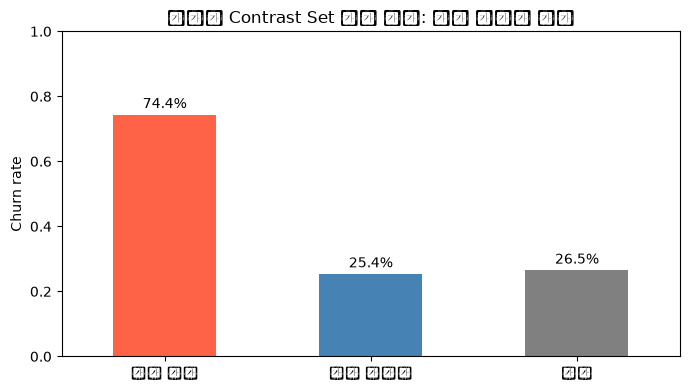


[검증 결론]
규칙 해당 이탈률 = 74.4%
규칙 비해당 이탈률 = 25.4%
전체 평균 이탈률   = 26.5%
→ 규칙 해당군의 이탈률이 전체/비해당보다 뚜렷히 높음 → 유의미한 규칙으로 판단 가능


In [18]:
# ============================================================
# Cell 1. 가장 중요한 규칙 → 실제 이탈률로 유의미성 검증
# ============================================================
# 검증 아이디어 (강의 P1=A & P3=A & C2_cut=High 검증과 동일):
#   1) 규칙에 해당하는 고객(mask=True)의 Churn 비율
#   2) 해당하지 않는 고객(mask=False)의 Churn 비율
#   3) 전체 평균 이탈률
#  → 규칙 해당군의 이탈률이 훨씬 높으면 "실제로 유의미"하다고 볼 수 있음

# 규칙 문자열이 잘리지 않게
pd.set_option("display.max_colwidth", None)

# group이 "Churn=>Yes" 형태일 수도, 이미 "Yes"만 남겼을 수도 있음
yes_rules = contrast_rules[
    contrast_rules["group"].astype(str).str.contains("Yes")
].sort_values("lift", ascending=False)

print("[Churn=Yes 상위 규칙]")
display(yes_rules.head(5))

# 가장 중요한 규칙 = lift 1등
top_rule = yes_rules.iloc[0]["rule"]
top_lift = yes_rules.iloc[0]["lift"]
print("\n>>> 검증 대상 규칙:", top_rule)
print(">>> lift:", round(top_lift, 4))


def rule_to_mask(df, rule):
    """
    ContrastSetLearner 규칙 예:
      ('Contract=>Month-to-month', 'tenure_cut=>tenure_Q1(짧음)')
    을 실제 DataFrame 조건(mask)으로 변환
    """
    # rule이 문자열로 들어올 경우도 대비
    if isinstance(rule, str):
        # "('A=>x', 'B=>y')" 형태를 튜플처럼 파싱
        parts = [p.strip(" '\"") for p in rule.strip("()").split(",") if "=>" in p]
    else:
        parts = list(rule)

    mask = pd.Series(True, index=df.index)
    parsed = []
    for item in parts:
        # "컬럼=>값" 분리
        col, val = item.split("=>", 1)
        col, val = col.strip(), val.strip()

        # 구간화 컬럼은 category일 수 있어 문자열로 맞춰 비교
        col_series = df[col].astype(str)
        mask &= (col_series == val)
        parsed.append((col, val))

    return mask, parsed


# ※ 구간화/원본 범주가 들어 있는 data(또는 contra_data)로 검증
#    tenure_cut 등이 data에 있어야 함
verify_df = data.copy()
# Churn이 분리되어 있다면 다시 붙이기
if "Churn" not in verify_df.columns:
    verify_df["Churn"] = churn

cset_mask, parsed_conds = rule_to_mask(verify_df, top_rule)
print("\n[파싱된 조건]")
for col, val in parsed_conds:
    print(f"  - {col} == {val}")

# (1) 규칙 해당 / 비해당 고객의 Churn 분포
print("\n[규칙 해당 고객] Churn 분포")
print(verify_df.loc[cset_mask, "Churn"].value_counts())
print("\n[규칙 비해당 고객] Churn 분포")
print(verify_df.loc[~cset_mask, "Churn"].value_counts())

# (2) 이탈률(비율) 비교
def churn_rate(series):
    return (series == "Yes").mean()

rate_in = churn_rate(verify_df.loc[cset_mask, "Churn"])
rate_out = churn_rate(verify_df.loc[~cset_mask, "Churn"])
rate_all = churn_rate(verify_df["Churn"])
n_in = cset_mask.sum()
n_out = (~cset_mask).sum()

summary = pd.DataFrame({
    "고객 수": [n_in, n_out, len(verify_df)],
    "이탈률": [rate_in, rate_out, rate_all],
    "전체 대비 배수": [rate_in / rate_all, rate_out / rate_all, 1.0],
}, index=["규칙 해당", "규칙 비해당", "전체"])

print("\n[이탈률 비교 요약]")
display(summary.style.format({
    "이탈률": "{:.1%}",
    "전체 대비 배수": "{:.2f}x",
}))

# (3) 막대 그래프
ax = summary["이탈률"].plot(kind="bar", color=["tomato", "steelblue", "gray"], figsize=(7, 4), rot=0)
ax.set_ylabel("Churn rate")
ax.set_title("최상위 Contrast Set 규칙 검증: 실제 이탈률 비교")
ax.set_ylim(0, 1)
for i, v in enumerate(summary["이탈률"]):
    ax.text(i, v + 0.02, f"{v:.1%}", ha="center")
plt.tight_layout()
plt.show()

# (4) 한 줄 판정
print("\n[검증 결론]")
print(f"규칙 해당 이탈률 = {rate_in:.1%}")
print(f"규칙 비해당 이탈률 = {rate_out:.1%}")
print(f"전체 평균 이탈률   = {rate_all:.1%}")
if rate_in > rate_all * 1.5 and rate_in > rate_out:
    print("→ 규칙 해당군의 이탈률이 전체/비해당보다 뚜렷히 높음 → 유의미한 규칙으로 판단 가능")
else:
    print("→ 차이가 작거나 불명확함 → 임계값·규칙 정의·샘플 수를 재검토할 것")

In [19]:
# ============================================================
# Cell 2. (선택) Churn=Yes 상위 3개 규칙을 나란히 검증
# ============================================================

rows = []
for i, row in yes_rules.head(3).iterrows():
    rule = row["rule"]
    mask, parsed = rule_to_mask(verify_df, rule)
    rate = churn_rate(verify_df.loc[mask, "Churn"])
    rows.append({
        "rule": rule,
        "lift": row["lift"],
        "n_match": int(mask.sum()),
        "churn_rate_match": rate,
        "churn_rate_rest": churn_rate(verify_df.loc[~mask, "Churn"]),
        "vs_all": rate / rate_all,
    })

comp = pd.DataFrame(rows)
display(comp.style.format({
    "lift": "{:.3f}",
    "churn_rate_match": "{:.1%}",
    "churn_rate_rest": "{:.1%}",
    "vs_all": "{:.2f}x",
}))

,rule,lift,n_match,churn_rate_match,churn_rate_rest,vs_all
0,"('Contract=>Month-to-month', 'tenure_cut=>tenure_Q1(짧음)', 'MonthlyCharges_cut=>Monthly_Q4(고요금)')",8.359,164,74.4%,25.4%,2.80x
1,"('InternetService=>Fiber optic', 'MonthlyCharges_cut=>Monthly_Q2', 'TotalCharges_cut=>Total_Q1(적음)')",8.014,121,71.1%,25.8%,2.68x
2,"('InternetService=>Fiber optic', 'StreamingMovies=>Yes', 'TotalCharges_cut=>Total_Q1(적음)')",6.906,145,80.0%,25.4%,3.01x


## 어떻게 읽으면 되나

| 비교 | 의미 |
|------|------|
| **규칙 해당 이탈률** | 이 조건 조합인 사람 중 실제로 떠난 비율 |
| **규칙 비해당 이탈률** | 그 조건이 아닌 사람의 이탈률 |
| **전체 이탈률** | 데이터셋 평균(대개 ~26~27%) |

판정 기준 예시:

- 해당군 이탈률이 전체보다 **훨씬 높고**(예: 1.5배 이상),  
- 비해당군보다도 높으면 → **규칙이 실제로도 유의미**

예상 패턴(1등 규칙이 Month-to-month + 단기 tenure라면):

- 해당군: 이탈률이 **매우 높게**(예: 50~70%대일 수 있음)  
- 비해당/전체: 그보다 **낮게**  

이렇게 나오면 STUCCO가 뽑은 lift 높은 규칙이 **실데이터에서도 설득력 있다**고 보고서/과제에 쓰면 됩니다.